# Model 2: Duration Band Prediction

**Objective:** Predict how long a Bengaluru traffic disruption will last at event-creation time.

**Target:** `duration_band`

- `short`: less than 1 hour
- `medium`: 1 to 4 hours
- `long`: more than 4 hours

**Primary metric:** Macro-F1, because the rare `long` class matters operationally.

This notebook uses the feature-engineered file `outputs/model_ready_duration_band.csv`. It also includes an optional section for adding Model 1 closure probabilities only when an aligned prediction file exists.

## 0. Install Dependencies

Run this cell first if your environment does not already have the ML stack installed. In Google Colab, run it once and then continue with the rest of the notebook.

## 1. Imports and Project Paths

This cell resolves the project root automatically, so the notebook works from Jupyter, VS Code, or Colab after the repo is mounted/copied.

In [131]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = exc

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'outputs').exists()), cwd)
DATA_PATH = PROJECT_ROOT/ 'outputs'/ 'model_road_closure'/ 'model2_duration_handoff.csv'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

print('Project root:', PROJECT_ROOT)
print('Data path:', DATA_PATH)
print('XGBoost available:', XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print('XGBoost import issue:', XGBOOST_IMPORT_ERROR)

Project root: D:\Python\Gridlock\Phase 2\theme 2
Data path: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_road_closure\model2_duration_handoff.csv
XGBoost available: True


## 2. Load Duration-Band Dataset

The feature engineering notebook already removed invalid durations and created the target. This notebook treats that file as the modeling contract.

In [132]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (3498, 162)


,id,_source_row,prediction_datetime,start_datetime,latitude,longitude,lat_round_3,lon_round_3,distance_to_city_center_km,start_hour,start_dayofweek,start_month_number,start_weekofyear,is_weekend,is_morning_peak,is_evening_peak,is_peak_hour,is_night,hour_sin,hour_cos,day_sin,day_cos,report_lag_minutes_clipped,report_lag_hours_clipped,description_missing,text_length,description_char_length,description_word_count,has_non_ascii_text,has_kannada_text,has_accident_word,has_breakdown_word,has_water_word,has_construction_word,has_event_word,has_blocked_word,has_jam_word,has_vip_word,has_location_hint_word,is_planned_event,is_public_or_vip_event,is_breakdown_event,is_accident_event,is_weather_or_visibility_event,is_road_condition_event,has_vehicle_type,is_truck,is_bus,is_heavy_vehicle,event_type,event_cause,veh_type,corridor,police_station,zone,junction,location_grid,peak_period,start_day_name,start_month_name,...,past_duration_count_event_cause,past_duration_q25_event_cause,past_duration_median_event_cause,past_duration_q75_event_cause,past_duration_rate_short_event_cause,past_duration_rate_medium_event_cause,past_duration_rate_long_event_cause,past_duration_rate_very_long_event_cause,past_duration_count_corridor,past_duration_q25_corridor,past_duration_median_corridor,past_duration_q75_corridor,past_duration_rate_short_corridor,past_duration_rate_medium_corridor,past_duration_rate_long_corridor,past_duration_rate_very_long_corridor,past_duration_count_zone,past_duration_q25_zone,past_duration_median_zone,past_duration_q75_zone,past_duration_rate_short_zone,past_duration_rate_medium_zone,past_duration_rate_long_zone,past_duration_rate_very_long_zone,past_duration_count_junction,past_duration_q25_junction,past_duration_median_junction,past_duration_q75_junction,past_duration_rate_short_junction,past_duration_rate_medium_junction,past_duration_rate_long_junction,past_duration_rate_very_long_junction,past_duration_count_police_station,past_duration_q25_police_station,past_duration_median_police_station,past_duration_q75_police_station,past_duration_rate_short_police_station,past_duration_rate_medium_police_station,past_duration_rate_long_police_station,past_duration_rate_very_long_police_station,past_duration_count_location_grid,past_duration_q25_location_grid,past_duration_median_location_grid,past_duration_q75_location_grid,past_duration_rate_short_location_grid,past_duration_rate_medium_location_grid,past_duration_rate_long_location_grid,past_duration_rate_very_long_location_grid,past_duration_count_event_cause_corridor,past_duration_q25_event_cause_corridor,past_duration_median_event_cause_corridor,past_duration_q75_event_cause_corridor,past_duration_rate_short_event_cause_corridor,past_duration_rate_medium_event_cause_corridor,past_duration_rate_long_event_cause_corridor,past_duration_rate_very_long_event_cause_corridor,duration_minutes_raw,duration_band,road_closure_probability,road_closure_probability_is_history_fallback
0,FKID005760,5760,2023-11-09 19:27:19.694644+00:00,2023-11-09 19:24:48.154000+00:00,12.966897,77.610555,12.967,77.611,1.806229,0.0,4.0,11.0,45,0,0,0,0,1,0.000000,1.000000e+00,-0.433884,-0.900969,2.525677,0.042095,0,129,35,7,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,unplanned,others,NaN,non-corridor,ashok nagar,central zone 1,d'souzacircle,12.967_77.611,night,friday,november,...,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,203.828038,medium,1.000000,1
1,FKID005197,5197,2023-11-09 20:53:11.012768+00:00,2023-11-09 20:51:36.296000+00:00,12.921773,77.585775,12.922,77.586,5.622409,2.0,4.0,11.0,45,0,0,0,0,1,0.500000,8.660254e-01,-0.433884,-0.900969,1.578613,0.026310,0,110,26,4,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,unplanned,water_logging,NaN,non-corridor,jayanagara,south zone 1,NaN,12.922_77.586,night,friday,november,...,0,NaN,

## 3. Basic Data Checks

These checks help confirm that the target exists, the class balance is understood, and the feature matrix is usable.

In [133]:
target_col = 'duration_band'
assert target_col in df.columns, f'Missing target column: {target_col}'

print('Rows:', len(df))
print('Columns:', len(df.columns))
print('\nTarget counts:')
display(df[target_col].value_counts(dropna=False).to_frame('count'))
print('\nTarget percentages:')
display((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame('percent'))

missing_target = df[target_col].isna().sum()
duplicate_columns = df.columns[df.columns.duplicated()].tolist()
print('\nMissing target rows:', missing_target)
print('Duplicate columns:', duplicate_columns if duplicate_columns else 'None')

Rows: 3498
Columns: 162

Target counts:


,count
duration_band,
short,1579
medium,903
very_long,736
long,280



Target percentages:


,percent
duration_band,
short,45.14
medium,25.81
very_long,21.04
long,8.00



Missing target rows: 0
Duplicate columns: None


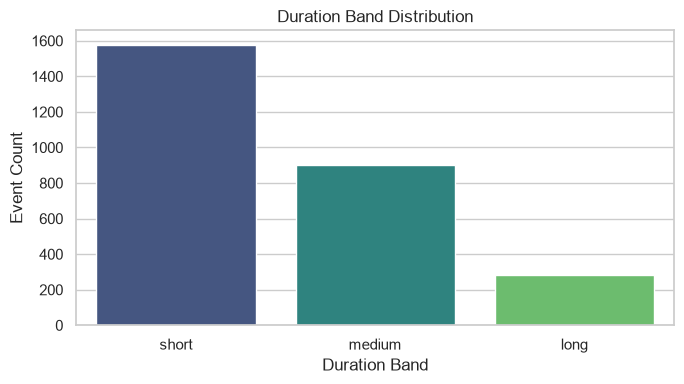

In [134]:
plt.figure(figsize=(7, 4))
order = ['short', 'medium', 'long']
sns.countplot(data=df, x=target_col, order=[c for c in order if c in df[target_col].unique()], palette='viridis')
plt.title('Duration Band Distribution')
plt.xlabel('Duration Band')
plt.ylabel('Event Count')
plt.tight_layout()
plt.show()

## 5. Feature Matrix and Target Encoding

The handoff file has 162 columns total. We keep the target column, remove obvious leakage/meta columns, and use the remaining columns as model features.

`prediction_datetime` and `start_datetime` are not used as model inputs here; they are kept only to verify the data is ordered correctly for time-aware evaluation.

After excluding the target and metadata columns, the usable feature matrix contains 157 columns.


In [135]:
leakage_or_non_feature_cols = [
    target_col,
    'duration_minutes',
    'duration_minutes_raw',
    'prediction_datetime',
    'start_datetime',
    '_source_row',
    'id',
]

exclude_cols = [c for c in leakage_or_non_feature_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in exclude_cols]

model_df = df.dropna(subset=[target_col]).copy()

# Keep timestamps only for ordering checks; they are not used as features.
for col in ['prediction_datetime', 'start_datetime']:
    if col in model_df.columns:
        model_df[col] = pd.to_datetime(model_df[col], errors='coerce', utc=True)

sort_cols = [c for c in ['prediction_datetime', 'start_datetime', '_source_row'] if c in model_df.columns]
if sort_cols:
    model_df = model_df.sort_values(
        sort_cols,
        kind='mergesort',
        na_position='last',
    ).reset_index(drop=True)

X = model_df[feature_cols].copy()
y_raw = model_df[target_col].astype(str).str.lower().str.strip()

# Coerce all features to numeric. Any accidental non-numeric column becomes NaN and is imputed below.
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

nan_counts = X.isna().sum()
cols_with_nan = nan_counts[nan_counts > 0]
if len(cols_with_nan):
    print('Columns with missing numeric values:', len(cols_with_nan))
    display(cols_with_nan.sort_values(ascending=False).head(20).to_frame('missing_count'))

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
inverse_label_mapping = {int(v): k for k, v in label_mapping.items()}

print('Feature matrix:', X.shape)
print('Label mapping:', label_mapping)
print('Feature dtypes:')
print(X.dtypes.value_counts())

if 'prediction_datetime' in model_df.columns:
    print('prediction_datetime is monotonic increasing:', bool(model_df['prediction_datetime'].is_monotonic_increasing))


Columns with missing numeric values: 46


,missing_count
event_type,3498
event_cause,3498
veh_type,3498
corridor,3498
police_station,3498
zone,3498
junction,3498
location_grid,3498
peak_period,3498
start_day_name,3498


Feature matrix: (3498, 156)
Label mapping: {'long': np.int64(0), 'medium': np.int64(1), 'short': np.int64(2), 'very_long': np.int64(3)}
Feature dtypes:
float64    101
int64       55
Name: count, dtype: int64
prediction_datetime is monotonic increasing: True


## 6. Train / Validation / Test Split

The file is already ordered by `prediction_datetime`, so we keep a chronological split to avoid leakage across time. The first 70% of rows are used for training, the next 15% for validation, and the final 15% for testing.

We do not use `prediction_datetime` itself as a model feature; it is used only to preserve the correct temporal order.


In [136]:
RANDOM_STATE = 42

n = len(X)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y[:train_end].copy()
y_val = y[train_end:val_end].copy()
y_test = y[val_end:].copy()

print('Train:', X_train.shape, pd.Series(y_train).map(inverse_label_mapping).value_counts().to_dict())
print('Val:  ', X_val.shape, pd.Series(y_val).map(inverse_label_mapping).value_counts().to_dict())
print('Test: ', X_test.shape, pd.Series(y_test).map(inverse_label_mapping).value_counts().to_dict())


Train:

 (2448, 156) {'short': 1144, 'medium': 638, 'very_long': 484, 'long': 182}
Val:   (525, 156) {'short': 194, 'very_long': 150, 'medium': 131, 'long': 50}
Test:  (525, 156) {'short': 241, 'medium': 134, 'very_long': 102, 'long': 48}


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score

cat_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    iterations=800,
    learning_rate=0.04,
    depth=5,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=100,
    auto_class_weights='Balanced',
    allow_writing_files=False
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

cat_val_pred = cat_model.predict(X_val).astype(int).ravel()

print("CatBoost - Validation")
print("Macro-F1:", f1_score(y_val, cat_val_pred, average='macro'))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, cat_val_pred))
print(classification_report(y_val, cat_val_pred, target_names=label_encoder.classes_))

0:	learn: 0.5421590	test: 0.4156904	best: 0.4156904 (0)	total: 181ms	remaining: 2m 24s
100:	learn: 0.6820697	test: 0.5317133	best: 0.5466603 (2)	total: 11.7s	remaining: 1m 20s
200:	learn: 0.7284066	test: 0.5511231	best: 0.5702304 (157)	total: 20.2s	remaining: 1m
300:	learn: 0.7674220	test: 0.5774845	best: 0.5797930 (292)	total: 27.3s	remaining: 45.3s


## 7. Baseline Model: Random Forest

This gives a sturdy comparison point before the main gradient-boosted model.

In [138]:
baseline_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline_model.fit(X_train, y_train)
baseline_val_pred = baseline_model.predict(X_val)
baseline_val_proba = baseline_model.predict_proba(X_val)

baseline_macro_f1 = f1_score(y_val, baseline_val_pred, average='macro')
baseline_bal_acc = balanced_accuracy_score(y_val, baseline_val_pred)

print('Baseline Random Forest - Validation')
print('Macro-F1:', round(baseline_macro_f1, 4))
print('Balanced Accuracy:', round(baseline_bal_acc, 4))
print('\nClassification Report:')
print(classification_report(y_val, baseline_val_pred, target_names=label_encoder.classes_))

Baseline Random Forest - Validation
Macro-F1: 0.5283
Balanced Accuracy: 0.5479

Classification Report:
              precision    recall  f1-score   support

        long       0.71      0.40      0.51        50
      medium       0.56      0.14      0.22       131
       short       0.64      0.70      0.67       194
   very_long       0.57      0.95      0.71       150

    accuracy                           0.60       525
   macro avg       0.62      0.55      0.53       525
weighted avg       0.61      0.60      0.55       525



## 8. Main Model: XGBoost Multi-Class Classifier

XGBoost is used for consistency with Model 1. If XGBoost is unavailable, this notebook falls back to the Random Forest baseline so the rest of the evaluation still runs.

In [139]:
train_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
val_sample_weight = compute_sample_weight(class_weight='balanced', y=y_val)

if XGBOOST_AVAILABLE:
    main_model = XGBClassifier(
        objective='multi:softprob',
        num_class=len(label_encoder.classes_),
        eval_metric='mlogloss',
        n_estimators=700,
        max_depth=4,
        learning_rate=0.035,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_lambda=2.0,
        reg_alpha=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    )

    main_model.fit(
        X_train,
        y_train,
        sample_weight=train_sample_weight,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    model_name = 'XGBoost'
else:
    main_model = baseline_model
    model_name = 'RandomForestFallback'

val_pred = main_model.predict(X_val)
val_proba = main_model.predict_proba(X_val)

val_macro_f1 = f1_score(y_val, val_pred, average='macro')
val_bal_acc = balanced_accuracy_score(y_val, val_pred)

print(f'{model_name} - Validation')
print('Macro-F1:', round(val_macro_f1, 4))
print('Balanced Accuracy:', round(val_bal_acc, 4))
print('\nClassification Report:')
print(classification_report(y_val, val_pred, target_names=label_encoder.classes_))

XGBoost - Validation
Macro-F1: 0.5068
Balanced Accuracy: 0.5247

Classification Report:
              precision    recall  f1-score   support

        long       0.63      0.38      0.47        50
      medium       0.39      0.47      0.43       131
       short       0.65      0.30      0.41       194
   very_long       0.57      0.95      0.71       150

    accuracy                           0.54       525
   macro avg       0.56      0.52      0.51       525
weighted avg       0.56      0.54      0.51       525



## 9. Validation Confusion Matrix

Read this matrix row-wise: each row is the actual class, each column is the predicted class.

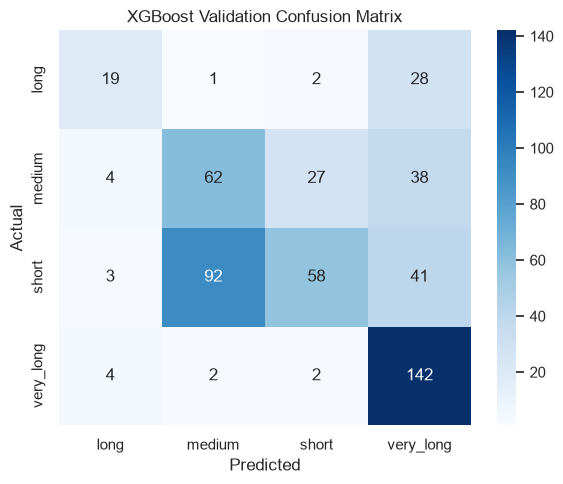

,long,medium,short,very_long
long,19,1,2,28
medium,4,62,27,38
short,3,92,58,41
very_long,4,2,2,142


In [140]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    return cm_df

val_cm_df = plot_confusion(y_val, val_pred, f'{model_name} Validation Confusion Matrix')
display(val_cm_df)

## 10. Final Test Evaluation

Only run this after you are happy with validation performance. This gives the held-out score for the final report.

XGBoost - Test Set
Accuracy: 0.419
Balanced Accuracy: 0.4418
Macro-F1: 0.3641
Weighted-F1: 0.3786

Classification Report:
              precision    recall  f1-score   support

        long       0.62      0.10      0.18        48
      medium       0.35      0.46      0.40       134
       short       0.74      0.22      0.34       241
   very_long       0.37      0.98      0.54       102

    accuracy                           0.42       525
   macro avg       0.52      0.44      0.36       525
weighted avg       0.56      0.42      0.38       525



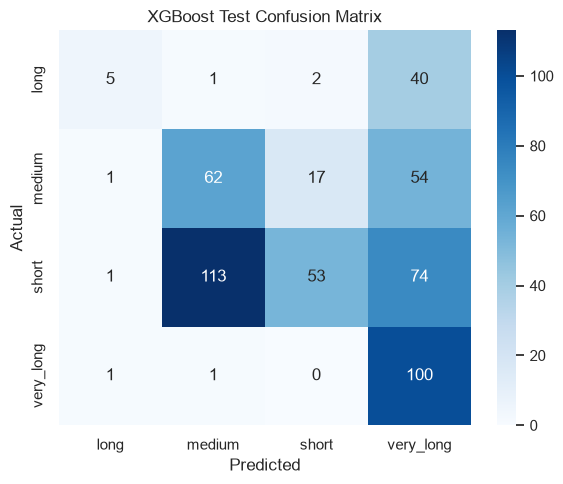

,long,medium,short,very_long
long,5,1,2,40
medium,1,62,17,54
short,1,113,53,74
very_long,1,1,0,100


In [141]:
test_pred = main_model.predict(X_test)
test_proba = main_model.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_bal_acc = balanced_accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average='macro')
test_weighted_f1 = f1_score(y_test, test_pred, average='weighted')

print(f'{model_name} - Test Set')
print('Accuracy:', round(test_accuracy, 4))
print('Balanced Accuracy:', round(test_bal_acc, 4))
print('Macro-F1:', round(test_macro_f1, 4))
print('Weighted-F1:', round(test_weighted_f1, 4))
print('\nClassification Report:')
print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

test_cm_df = plot_confusion(y_test, test_pred, f'{model_name} Test Confusion Matrix')
display(test_cm_df)

## 11. Per-Class Recall Check

For operations, recall on `long` is especially important because missing long disruptions is costly.

In [142]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_pred, zero_division=0)
per_class_metrics = pd.DataFrame({
    'class': label_encoder.classes_,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support,
}).sort_values('class')

display(per_class_metrics)

if 'long' in label_encoder.classes_:
    long_idx = int(np.where(label_encoder.classes_ == 'long')[0][0])
    print('Long-class recall:', round(float(recall[long_idx]), 4))

,class,precision,recall,f1,support
0,long,0.625000,0.104167,0.178571,48
1,medium,0.350282,0.462687,0.398714,134
2,short,0.736111,0.219917,0.338658,241
3,very_long,0.373134,0.980392,0.540541,102


Long-class recall: 0.1042


## 12. Prediction Probability Output

This creates an interpretable table with actual label, predicted label, confidence, and one probability column per duration band.

In [143]:
proba_cols = [f'prob_{label}' for label in label_encoder.classes_]

predictions_df = pd.DataFrame(test_proba, columns=proba_cols, index=X_test.index)
predictions_df.insert(0, 'actual_duration_band', label_encoder.inverse_transform(y_test))
predictions_df.insert(1, 'predicted_duration_band', label_encoder.inverse_transform(test_pred))
predictions_df.insert(2, 'prediction_confidence', test_proba.max(axis=1))
predictions_df.insert(3, 'source_row_index', X_test.index)

predictions_df = predictions_df.sort_index().reset_index(drop=True)
display(predictions_df.head(20))

,actual_duration_band,predicted_duration_band,prediction_confidence,source_row_index,prob_long,prob_medium,prob_short,prob_very_long
0,short,short,0.530155,2973,0.000292,0.468229,0.530155,0.001324
1,medium,medium,0.854912,2974,0.000467,0.854912,0.143016,0.001606
2,short,medium,0.533910,2975,0.000566,0.533910,0.464491,0.001033
3,short,very_long,0.796685,2976,0.137148,0.025750,0.040417,0.796685
4,short,very_long,0.798928,2977,0.047963,0.112020,0.041089,0.798928
5,short,medium,0.855498,2978,0.000482,0.855498,0.143054,0.000966
6,short,medium,0.909962,2979,0.000340,0.909962,0.088521,0.001177
7,very_long,very_long,0.921090,2980,0.032736,0.014364,0.031810,0.921090
8,long,very_long,0.651715,2981,0.282918,0.033248,0.032119,0.651715
9,short,medium,0.511072,2982,0.000179,0.511072,0.486637,0.002111


## 13. Feature Importance

For XGBoost, this uses model gain/importance. For the fallback Random Forest, it uses impurity importance.

,feature,importance
37,is_breakdown_event,0.069960
101,past_duration_q75_event_cause,0.060595
41,has_vehicle_type,0.059913
102,past_duration_rate_short_event_cause,0.044441
29,has_construction_word,0.039939
38,is_accident_event,0.024050
35,is_planned_event,0.023742
77,past_closure_rate_event_cause,0.021956
104,past_duration_rate_long_event_cause,0.017911
152,past_duration_rate_long_event_cause_corridor,0.017696


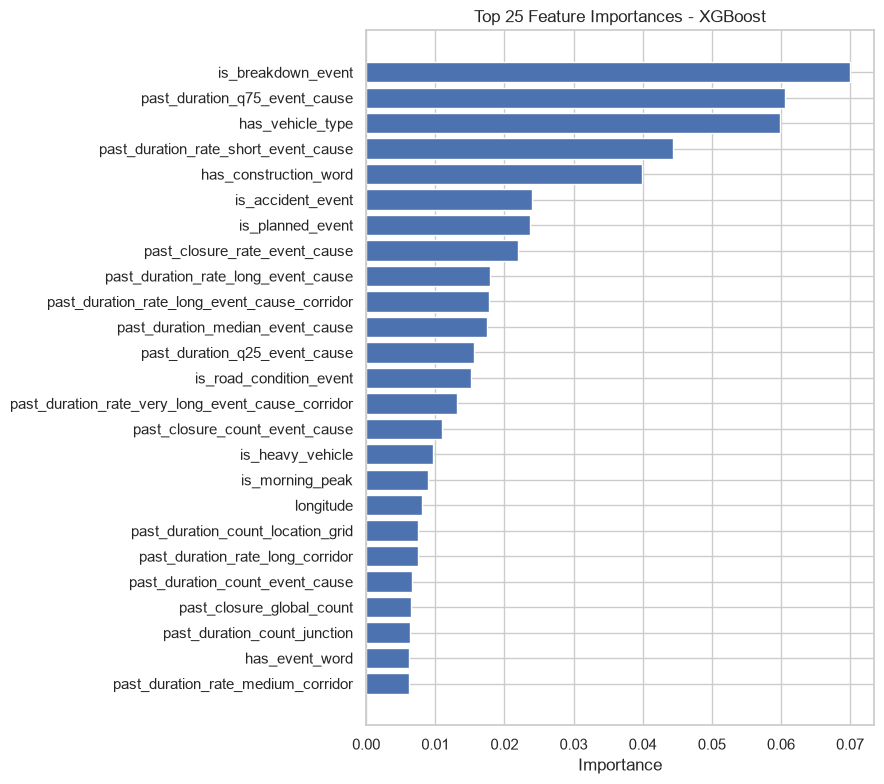

In [144]:
if hasattr(main_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': main_model.feature_importances_,
    }).sort_values('importance', ascending=False)
else:
    feature_importance = pd.DataFrame(columns=['feature', 'importance'])

display(feature_importance.head(30))

plt.figure(figsize=(9, 8))
top_features = feature_importance.head(25).iloc[::-1]
plt.barh(top_features['feature'], top_features['importance'])
plt.title(f'Top 25 Feature Importances - {model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 14. Optional Permutation Importance

This is slower, but often more trustworthy than built-in tree importance. Run it when you want a deeper model check.

In [145]:
RUN_PERMUTATION_IMPORTANCE = True

if RUN_PERMUTATION_IMPORTANCE:
    perm = permutation_importance(
        main_model,
        X_val,
        y_val,
        scoring='f1_macro',
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    perm_df = pd.DataFrame({
        'feature': X_val.columns,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(perm_df.head(30))
else:
    print('Skipped. Set RUN_PERMUTATION_IMPORTANCE = True to run this check.')

,feature,importance_mean,importance_std
37,is_breakdown_event,0.013627,0.010246
112,past_duration_rate_long_corridor,0.010607,0.008038
14,hour_sin,0.009360,0.005265
35,is_planned_event,0.008658,0.001802
102,past_duration_rate_short_event_cause,0.007618,0.008155
136,past_duration_rate_long_police_station,0.007266,0.005056
99,past_duration_q25_event_cause,0.005063,0.002197
75,past_closure_global_rate,0.004881,0.002251
97,past_duration_global_rate_very_long,0.004186,0.000783
4,distance_to_city_center_km,0.004082,0.009520


## 15. Save Artifacts

This saves the model, label mapping, metrics, feature importances, and test predictions.

In [146]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
model_output_dir = OUTPUTS_DIR / 'model_duration_band'
model_output_dir.mkdir(parents=True, exist_ok=True)

model_artifact = {
    'model': main_model,
    'model_name': model_name,
    'feature_cols': feature_cols,
    'label_encoder': label_encoder,
    'label_mapping': label_mapping,
    'inverse_label_mapping': inverse_label_mapping,
}

model_path = model_output_dir / 'model2_v1_duration_band_model.pkl'
predictions_path = model_output_dir / 'model2_v1_duration_band_predictions.csv'
importance_path = model_output_dir / 'model2_v1_duration_band_feature_importance.csv'
handoff_path = model_output_dir / 'model2_v1_duration_band_recommendation_handoff.csv'

# Build a recommendation-ready handoff that preserves the original row context
# for the downstream engine while adding the duration prediction outputs.
recommendation_handoff_df = model_df.loc[X_test.index].copy()
recommendation_handoff_df = pd.concat(
    [recommendation_handoff_df.reset_index(drop=True), predictions_df.reset_index(drop=True)],
    axis=1,
)

# Keep only the exact final handoff schema requested for downstream use.
final_handoff_columns = [
    'id',
    '_source_row',
    'prediction_datetime',
    'start_datetime',
    'latitude',
    'longitude',
    'location_grid',
    'distance_band',
    'address',
    'event_type',
    'event_cause',
    'veh_type',
    'corridor',
    'police_station',
    'zone',
    'junction',
    'start_hour',
    'start_dayofweek',
    'start_month_number',
    'is_weekend',
    'is_morning_peak',
    'is_evening_peak',
    'is_peak_hour',
    'is_night',
    'peak_period',
    'report_lag_minutes_clipped',
    'distance_to_city_center_km',
    'description',
    'is_planned_event',
    'is_public_or_vip_event',
    'is_breakdown_event',
    'is_accident_event',
    'is_weather_or_visibility_event',
    'is_road_condition_event',
    'is_heavy_vehicle',
    'has_blocked_word',
    'has_jam_word',
    'has_lane_word',
    'has_full_blockage_phrase',
    'has_partial_blockage_phrase',
    'has_diversion_word',
    'has_severity_word',
    'has_tree_fall_word',
    'target_road_closure',
    'valid_duration_label',
    'duration_band',
    'road_closure_probability',
    'predicted_label',
    'road_closure_probability_is_history_fallback',
    'predicted_duration_band',
    'prediction_confidence',
    'prob_short',
    'prob_medium',
    'prob_long',
    'prob_very_long',
]

recommendation_handoff_df = recommendation_handoff_df.reindex(
    columns=final_handoff_columns
)

joblib.dump(model_artifact, model_path)
predictions_df.to_csv(predictions_path, index=False)
feature_importance.to_csv(importance_path, index=False)
recommendation_handoff_df.to_csv(handoff_path, index=False)

metrics = {
    'model_name': model_name,
    'test_accuracy': float(test_accuracy),
    'test_balanced_accuracy': float(test_bal_acc),
    'test_macro_f1': float(test_macro_f1),
    'test_weighted_f1': float(test_weighted_f1),
    'label_mapping': {k: int(v) for k, v in label_mapping.items()},
    'train_rows': int(len(X_train)),
    'validation_rows': int(len(X_val)),
    'test_rows': int(len(X_test)),
    'feature_count': int(X.shape[1]),
    #'used_model1_probability': model1_feature_name in X.columns,
}

print('Saved model:', model_path)
print('Saved predictions:', predictions_path)
print('Saved feature importance:', importance_path)
print('Saved recommendation handoff:', handoff_path)
print('Recommendation handoff rows/cols:', recommendation_handoff_df.shape)
print('Recommendation handoff columns:', recommendation_handoff_df.columns.tolist())

Saved model: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_duration_band\model2_v1_duration_band_model.pkl
Saved predictions: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_duration_band\model2_v1_duration_band_predictions.csv
Saved feature importance: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_duration_band\model2_v1_duration_band_feature_importance.csv
Saved recommendation handoff: D:\Python\Gridlock\Phase 2\theme 2\outputs\model_duration_band\model2_v1_duration_band_recommendation_handoff.csv
Recommendation handoff rows/cols: (525, 55)
Recommendation handoff columns: ['id', '_source_row', 'prediction_datetime', 'start_datetime', 'latitude', 'longitude', 'location_grid', 'distance_band', 'address', 'event_type', 'event_cause', 'veh_type', 'corridor', 'police_station', 'zone', 'junction', 'start_hour', 'start_dayofweek', 'start_month_number', 'is_weekend', 'is_morning_peak', 'is_evening_peak', 'is_peak_hour', 'is_night', 'peak_period', 'report_lag_minutes_clipped', 'distanc

## 16. Single-Event Prediction Helper

Use this to test one row from the dataset and inspect the predicted duration band plus probabilities.

In [147]:
def predict_duration_band(row_or_df):
    if isinstance(row_or_df, pd.Series):
        event_df = row_or_df.to_frame().T
    else:
        event_df = row_or_df.copy()

    event_X = event_df[feature_cols].copy()
    for col in event_X.columns:
        event_X[col] = pd.to_numeric(event_X[col], errors='coerce')
    event_X = event_X.replace([np.inf, -np.inf], np.nan)
    event_X = event_X.fillna(X_train.median(numeric_only=True)).fillna(0)

    proba = main_model.predict_proba(event_X)
    pred = main_model.predict(event_X)

    result = pd.DataFrame(proba, columns=[f'prob_{label}' for label in label_encoder.classes_])
    result.insert(0, 'predicted_duration_band', label_encoder.inverse_transform(pred))
    result.insert(1, 'prediction_confidence', proba.max(axis=1))
    return result

sample_row = model_df.iloc[[0]].copy()
print('Actual duration band:', sample_row[target_col].iloc[0])
display(predict_duration_band(sample_row))

Actual duration band: medium


,predicted_duration_band,prediction_confidence,prob_long,prob_medium,prob_short,prob_very_long
0,medium,0.740076,0.005919,0.740076,0.019454,0.234551


## 17. Final Validation Summary

Use this cell at the end to print the numbers that belong in the project report.

In [148]:
print('=' * 72)
print('MODEL 2: DURATION BAND CLASSIFIER SUMMARY')
print('=' * 72)
print('Dataset:', DATA_PATH.name)
print('Rows used:', len(model_df))
print('Features:', X.shape[1])
print('Model:', model_name)
print('Used Model 1 probability:', model1_feature_name in X.columns)
print('Test Accuracy:', round(test_accuracy, 4))
print('Test Balanced Accuracy:', round(test_bal_acc, 4))
print('Test Macro-F1:', round(test_macro_f1, 4))
print('Test Weighted-F1:', round(test_weighted_f1, 4))
print('\nPer-class metrics:')
display(per_class_metrics)
print('\nArtifacts:')
print('-', model_path)
print('-', predictions_path)
print('-', importance_path)
print('=' * 72)

MODEL 2: DURATION BAND CLASSIFIER SUMMARY
Dataset: model2_duration_handoff.csv
Rows used: 3498
Features: 156
Model: XGBoost
Used Model 1 probability: False
Test Accuracy: 0.419
Test Balanced Accuracy: 0.4418
Test Macro-F1: 0.3641
Test Weighted-F1: 0.3786

Per-class metrics:


,class,precision,recall,f1,support
0,long,0.625000,0.104167,0.178571,48
1,medium,0.350282,0.462687,0.398714,134
2,short,0.736111,0.219917,0.338658,241
3,very_long,0.373134,0.980392,0.540541,102



Artifacts:
- D:\Python\Gridlock\Phase 2\theme 2\outputs\model_duration_band\model2_v1_duration_band_model.pkl
- D:\Python\Gridlock\Phase 2\theme 2\outputs\model_duration_band\model2_v1_duration_band_predictions.csv
- D:\Python\Gridlock\Phase 2\theme 2\outputs\model_duration_band\model2_v1_duration_band_feature_importance.csv
